# Phase 5 · 02 — Why did the model flag this transaction?

An analyst actions an alert from **reason codes**, not from a score. This notebook explains both models on real 2019 alerts, with values that are *exact* — not sampled approximations — so they can be trusted line by line.

| model | method | unit | cost per alert |
|---|---|---|---|
| XGBoost (@champion) | exact TreeSHAP (`pred_contribs`) folded to source fields | log-odds | microseconds |
| GraphSAGE (@challenger) | exact Shapley over 5 groups of its request subgraph | log-odds | 32 forward passes, ~0.2 s |

GraphSAGE's groups are the questions an analyst asks: was it **the transaction itself**, **how fast the card was spending** (velocity), **the card's history**, **the merchant's history**, or **who the card and merchant are** (identity codes)? Each group is removed along a path the model already knows — empty history, an unseen card, a typical transaction — so "absent" never means an input the model was not trained on (`src/fraud/explain/graph.py`).

Both are in log-odds, so the two models' explanations are on the same scale. Kernel: `fraud` (`.venv`, XGBoost 3.4).

In [1]:
import os, datetime as dt, warnings
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import shap, torch

from fraud.config import load_params, repo_path
from fraud.api.predictor import Predictor, transaction_from_row
from fraud.explain import tree as T, graph as G

warnings.filterwarnings("ignore")
torch.set_num_threads(1)                       # decision 20
pl.Config.set_tbl_rows(25); pl.Config.set_fmt_str_lengths(90); pl.Config.set_tbl_width_chars(160)

params = load_params()
cfg = params["explain"]
SAMPLE = bool(os.getenv("FRAUD_NOTEBOOK_SAMPLE"))
N_ALERTS = 2 if SAMPLE else cfg["n_alerts"] // 2      # per kind: true and false positives
GLOBAL = 2_000 if SAMPLE else cfg["global_sample"]

champion = T.load_champion(params)
# The weights the causal replay scored -- the same ones @challenger v3 serves (decision 23).
gnn = Predictor.from_disk(params, repo_path(params["paths"]["models"]) / "gnn")
print("XGBoost:", len(champion.feature_names), "features | GraphSAGE:", gnn.model_version, "| sample mode:", SAMPLE)

/teamspace/studios/this_studio/financial-fraud-detection/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/teamspace/studios/this_studio/financial-fraud-detection/.venv/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


XGBoost: 86 features | GraphSAGE: gnn-local-epoch19 | sample mode: False


## 1 · What XGBoost leans on overall

Mean |SHAP| per **source field** on a 2019 sample — the 86 encoded columns folded back into the 24 fields they came from. Folding is exact because SHAP values are additive.

efficiency: max |sum(SHAP) - margin| = 1.1444091796875e-05


matches the shap library to 0.0


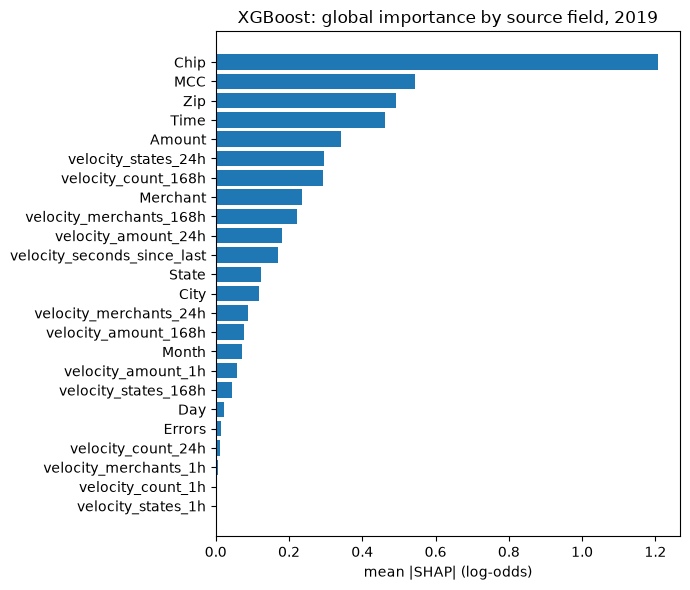

In [2]:
sample = T.matrix_rows(params, years=[2019]).sample(GLOBAL, seed=0)
x = sample.select(champion.feature_names).to_numpy().astype(np.float32)
phi = T.contributions(champion, x)
fields, folded = T.fold(phi, champion.feature_names)

print("efficiency: max |sum(SHAP) - margin| =", float(np.abs(phi.sum(1) - champion.margin(x)).max()))
lib = shap.TreeExplainer(champion.booster).shap_values(x[:500])
print("matches the shap library to", float(np.abs(lib - phi[:500, :-1]).max()))

importance = pl.DataFrame({"field": fields, "mean_abs_shap": np.abs(folded[:, :-1]).mean(0)}).sort("mean_abs_shap")
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(importance["field"], importance["mean_abs_shap"])
ax.set_xlabel("mean |SHAP| (log-odds)"); ax.set_title("XGBoost: global importance by source field, 2019")
plt.tight_layout(); plt.show()

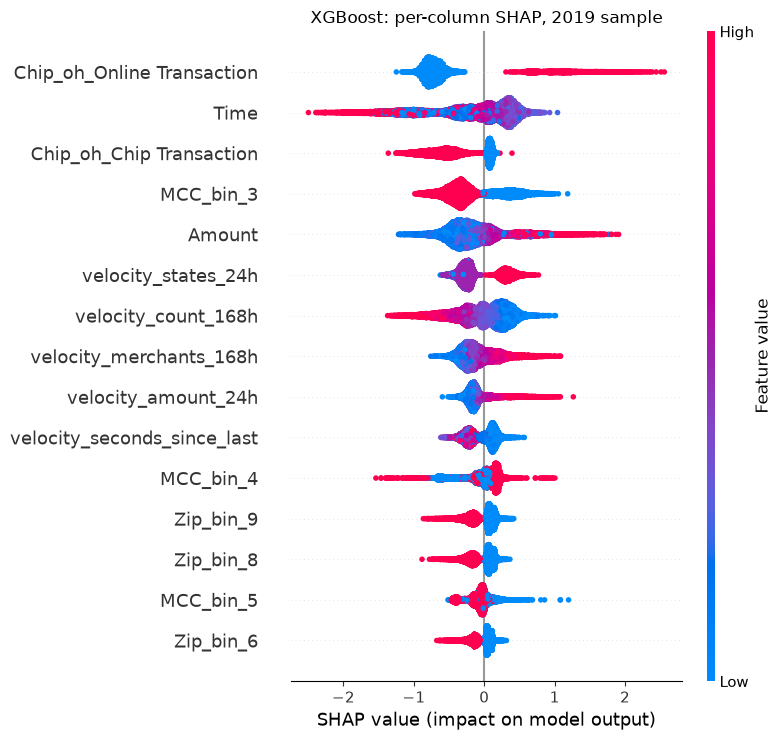

In [3]:
shap.summary_plot(phi[:, :-1], x, feature_names=champion.feature_names, max_display=15, show=False)
plt.title("XGBoost: per-column SHAP, 2019 sample"); plt.tight_layout(); plt.show()

## 2 · Alerts to explain

From each model's 2019 scores, the highest-scored **true positives** and **false positives**. False positives matter as much: they are the alerts that cost an analyst's time and a customer's patience, and the explanation is what lets someone dismiss one quickly.

In [4]:
def pick(path, n):
    z = np.load(repo_path(path))
    frame = pl.DataFrame({"txn_id": z["txn_id"], "score": z["score"], "label": z["label"]}).sort("score", descending=True)
    return pl.concat([frame.filter(pl.col("label") == 1).head(n), frame.filter(pl.col("label") == 0).head(n)])

alerts_x = pick(params["monitoring"]["scores"]["xgboost"]["analysis"], N_ALERTS)
alerts_g = pick(params["monitoring"]["scores"]["graphsage"]["analysis"], N_ALERTS)
ids = sorted(set(alerts_x["txn_id"].to_list()) | set(alerts_g["txn_id"].to_list()))
print(len(ids), "transactions to explain with both models")

36 transactions to explain with both models


## 3 · XGBoost reason codes

In [5]:
rows = T.matrix_rows(params, txn_ids=ids, years=[2019])
xgb_reasons = T.explain_rows(champion, rows, cfg["top_k_reasons"])
(alerts_x.select("txn_id", pl.col("label").alias("fraud"))
 .join(xgb_reasons.drop("fraud"), on="txn_id").sort("score", descending=True)
 .select("txn_id", "fraud", pl.col("score").round(4), "reasons"))

txn_id,fraud,score,reasons
i64,i8,f64,str
2018511,1,0.9854,"""MCC (+1.70) · Zip (+1.51) · Errors (+1.28) · City (+1.04) · velocity_count_168h (+0.91)"""
2458564,0,0.9721,"""Chip (+2.08) · Amount (+1.10) · MCC (+0.95) · velocity_merchants_24h (+0.94) · velocity_me…"
21864257,1,0.9643,"""Zip (+1.58) · velocity_amount_24h (+1.32) · velocity_merchants_24h (+0.95) · MCC (+0.94) ·…"
22896702,1,0.9627,"""Amount (+1.96) · Zip (+1.61) · MCC (+1.19) · City (+1.03) · velocity_amount_24h (+0.77)"""
20807852,0,0.95,"""Chip (+2.83) · MCC (+2.28) · Amount (+1.44) · Zip (+0.58) · Merchant (+0.52)"""
8632465,0,0.9333,"""Chip (+2.96) · MCC (+1.30) · velocity_amount_24h (+0.72) · Zip (+0.71) · velocity_states_2…"
9739745,1,0.9298,"""MCC (+1.48) · Zip (+1.43) · velocity_merchants_24h (+1.24) · City (+1.00) · velocity_state…"
6168543,0,0.9285,"""Chip (+3.04) · MCC (+1.26) · Zip (+0.55) · velocity_states_24h (+0.51) · velocity_amount_2…"
12301137,0,0.9267,"""Chip (+2.82) · MCC (+1.81) · Amount (+1.36) · Merchant (+0.99) · Zip (+0.62)"""


## 4 · GraphSAGE group Shapley

Each transaction's neighbourhood is rebuilt with `seed_rows` — the same past the causal replay showed the model — and then all 32 coalitions of the five groups are scored. The full coalition must reproduce the served score exactly; the values must sum to it.

In [6]:
processed = (pl.scan_parquet(repo_path(params["paths"]["processed"]) / "**/*.parquet", hive_partitioning=True)
             .filter(pl.col("txn_id").is_in(ids)).collect().sort("ts"))
graph_since = dt.datetime(2019, 1, 1) - dt.timedelta(hours=params["serving"]["history_hours"])
typical = G.typical_transaction(params, 2018, sample=50_000 if SAMPLE else 200_000)
print("typical transaction (the 'transaction absent' baseline):", typical)

results, served = {}, {}
for row in processed.iter_rows(named=True):
    txn = transaction_from_row(row)
    nb = G.neighbourhood_for(params, txn, graph_since)
    results[txn["txn_id"]] = G.explain(gnn, txn, nb, typical)
    served[txn["txn_id"]] = gnn.score(txn, nb).score

errors = G.efficiency_errors(results)
match = max(abs(results[t].score - served[t]) for t in results)
print(f"efficiency: max |sum(phi) - (full - baseline)| = {errors.max():.1e}   |   full coalition vs served score: {match:.1e}")

typical transaction (the 'transaction absent' baseline): {'Amount': 29.25, 'City': ' ONLINE', 'State': 'XX', 'Zip': 39305, 'Errors': 'XX', 'Chip': 'Chip Transaction', 'Time': 761, 'Month': 7, 'Day': 16}


efficiency: max |sum(phi) - (full - baseline)| = 3.6e-15   |   full coalition vs served score: 7.8e-08


In [7]:
groups_g = G.as_frame(results)
view = (alerts_g.select("txn_id", pl.col("label").alias("fraud"))
        .join(groups_g, on="txn_id").sort("score", descending=True))
view.select("txn_id", "fraud", pl.col("score").round(4), *[pl.col(g).round(2) for g in G.GROUPS], "top_group")

txn_id,fraud,score,transaction,velocity,card_history,merchant_history,identity,top_group
i64,i8,f64,f64,f64,f64,f64,f64,str
8443998,0,1.0,-2.45,24.84,-2.92,1.1,-0.09,"""velocity"""
12301137,0,1.0,8.07,4.08,0.57,5.4,-0.59,"""transaction"""
6812131,0,1.0,8.64,10.54,-0.97,0.48,-1.25,"""velocity"""
21864260,1,1.0,6.89,8.31,-0.13,1.89,0.35,"""velocity"""
14847773,0,1.0,6.86,6.25,1.28,2.57,-0.15,"""transaction"""
14656442,1,1.0,7.12,6.16,0.34,1.59,1.31,"""transaction"""
18387189,1,1.0,5.24,8.11,1.36,0.73,0.71,"""velocity"""
13334209,0,1.0,7.82,4.45,0.41,2.61,0.75,"""transaction"""
14656444,1,0.9999,6.9,7.72,0.21,1.86,-0.87,"""velocity"""


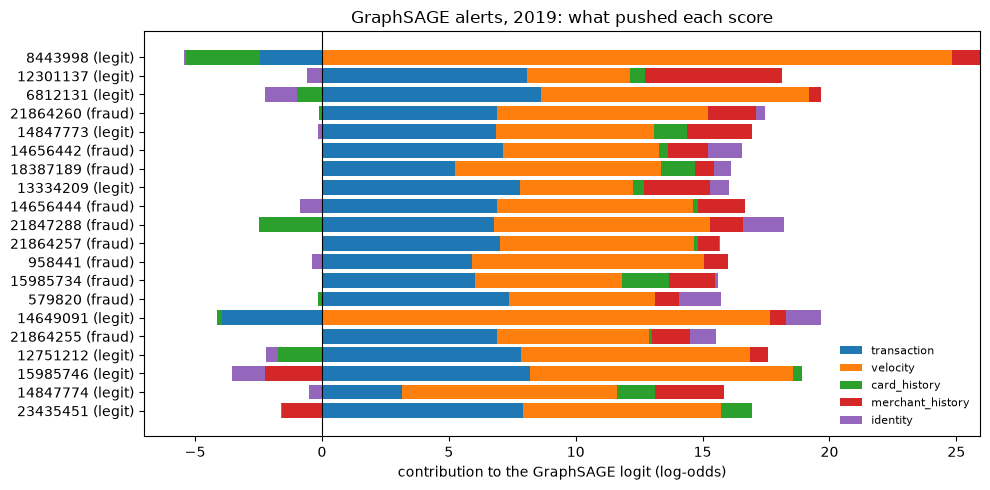

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
labels_ = [f"{t} ({'fraud' if f else 'legit'})" for t, f in zip(view["txn_id"], view["fraud"])]
left_pos = np.zeros(view.height); left_neg = np.zeros(view.height)
for g in G.GROUPS:
    vals = view[g].to_numpy()
    pos, neg = np.clip(vals, 0, None), np.clip(vals, None, 0)
    ax.barh(labels_, pos, left=left_pos, label=g); left_pos += pos
    ax.barh(labels_, neg, left=left_neg, color=ax.patches[-1].get_facecolor()); left_neg += neg
ax.axvline(0, c="k", lw=0.8); ax.invert_yaxis()
ax.set_xlabel("contribution to the GraphSAGE logit (log-odds)")
ax.set_title("GraphSAGE alerts, 2019: what pushed each score"); ax.legend(frameon=False, fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

## 5 · Same transaction, two models

For every explained alert: what each model would tell the analyst. Where they agree, the reason is robust; where they disagree, the graph is seeing something the tabular model cannot (or the reverse).

In [9]:
both = (pl.DataFrame({"txn_id": ids})
        .join(processed.select("txn_id", pl.col("Fraud").alias("fraud"), "Amount", "Chip", "MCC"), on="txn_id")
        .join(xgb_reasons.select("txn_id", pl.col("score").alias("xgb_score"), pl.col("top_field").alias("xgb_top")), on="txn_id")
        .join(groups_g.select("txn_id", pl.col("score").alias("gnn_score"), pl.col("top_group").alias("gnn_top"),
                              *G.GROUPS), on="txn_id")
        .sort("gnn_score", descending=True))
both.select("txn_id", "fraud", pl.col("xgb_score").round(3), "xgb_top", pl.col("gnn_score").round(3), "gnn_top", "Amount", "Chip")

txn_id,fraud,xgb_score,xgb_top,gnn_score,gnn_top,Amount,Chip
i64,i8,f64,str,f64,str,f64,str
8443998,0,0.004,"""velocity_amount_24h""",1.0,"""velocity""",13.7,"""Chip Transaction"""
12301137,0,0.927,"""Chip""",1.0,"""transaction""",1567.11,"""Online Transaction"""
6812131,0,0.485,"""Chip""",1.0,"""velocity""",1138.61,"""Online Transaction"""
21864260,1,0.672,"""Zip""",1.0,"""velocity""",11.97,"""Swipe Transaction"""
14847773,0,0.661,"""Zip""",1.0,"""transaction""",287.17,"""Swipe Transaction"""
14656442,1,0.898,"""Zip""",1.0,"""transaction""",1.34,"""Swipe Transaction"""
18387189,1,0.871,"""velocity_amount_24h""",1.0,"""velocity""",46.97,"""Chip Transaction"""
13334209,0,0.121,"""Zip""",1.0,"""transaction""",-279.0,"""Swipe Transaction"""
14656444,1,0.865,"""Zip""",1.0,"""velocity""",49.68,"""Swipe Transaction"""


In [10]:
share = (groups_g.select([pl.col(g).clip(lower_bound=0).alias(g) for g in G.GROUPS])
         .sum().transpose(include_header=True, header_name="group", column_names=["positive_log_odds"])
         .with_columns((pl.col("positive_log_odds") / pl.col("positive_log_odds").sum()).round(3).alias("share")))
print("Across the explained GraphSAGE alerts, where the push toward 'fraud' came from:")
share.sort("share", descending=True)

Across the explained GraphSAGE alerts, where the push toward 'fraud' came from:


group,positive_log_odds,share
str,f64,f64
"""velocity""",268.627733,0.471
"""transaction""",234.20379,0.411
"""merchant_history""",39.637465,0.07
"""identity""",17.722383,0.031
"""card_history""",9.815392,0.017


In [11]:
out = repo_path("reports/explain"); out.mkdir(parents=True, exist_ok=True)
if not SAMPLE:
    xgb_reasons.write_parquet(out / "xgboost_reason_codes.parquet")
    groups_g.write_parquet(out / "graphsage_group_shapley.parquet")
    importance.write_csv(out / "xgboost_global_importance.csv")
print("saved" if not SAMPLE else "sample mode: nothing saved")

saved


## 6 · Where does the graph earn its 2x?

The top alerts above are saturated near 1.0, and there the graph groups barely move the score. GraphSAGE's lead comes from somewhere else: in each model's top 5,000 alerts it catches **1,544 frauds to XGBoost's 1,156**. So we explain three sets of 2019 frauds:

| set | definition |
|---|---|
| **graph wins** | GraphSAGE rank ≤ 5,000, XGBoost rank > 20,000 (all of them) |
| **graph edge** | GraphSAGE rank ≤ 5,000, XGBoost rank 5,001–20,000 (a sample) |
| **both catch** | both ranks ≤ 5,000 (a sample) |

If relational structure is what wins, the card- and merchant-history groups should carry more of the push in *graph wins* than in *both catch*.

In [12]:
g = np.load(repo_path("reports/metrics_replay.npz")); xs = np.load(repo_path(params["monitoring"]["scores"]["xgboost"]["analysis"]))
ranks = (pl.DataFrame({"txn_id": g["txn_id"], "gnn": g["score"], "label": g["label"]})
         .with_columns(pl.col("gnn").rank("ordinal", descending=True).alias("gnn_rank"))
         .join(pl.DataFrame({"txn_id": xs["txn_id"], "xgb": xs["score"]})
               .with_columns(pl.col("xgb").rank("ordinal", descending=True).alias("xgb_rank")), on="txn_id")
         .filter(pl.col("label") == 1))
per_set = 3 if SAMPLE else 50
sets = {
    "graph wins": ranks.filter((pl.col("gnn_rank") <= 5000) & (pl.col("xgb_rank") > 20000)),
    "graph edge": ranks.filter((pl.col("gnn_rank") <= 5000) & pl.col("xgb_rank").is_between(5001, 20000)),
    "both catch": ranks.filter((pl.col("gnn_rank") <= 5000) & (pl.col("xgb_rank") <= 5000)),
}
sets = {k: (v if k == "graph wins" and not SAMPLE else v.sample(min(per_set, v.height), seed=0)) for k, v in sets.items()}
print({k: v.height for k, v in sets.items()})

wanted = sorted({t for v in sets.values() for t in v["txn_id"].to_list()})
mid_rows = (pl.scan_parquet(repo_path(params["paths"]["processed"]) / "**/*.parquet", hive_partitioning=True)
            .filter(pl.col("txn_id").is_in(wanted)).collect().sort("ts"))
mid = {}
for row in mid_rows.iter_rows(named=True):
    txn = transaction_from_row(row)
    mid[txn["txn_id"]] = G.explain(gnn, txn, G.neighbourhood_for(params, txn, graph_since), typical)
print(f"explained {len(mid)} frauds; efficiency max error {G.efficiency_errors(mid).max():.1e}")

{'graph wins': 51, 'graph edge': 50, 'both catch': 50}


explained 151 frauds; efficiency max error 1.8e-15


In [13]:
def profile(name, ids):
    f = G.as_frame({t: mid[t] for t in ids})
    pos = f.select([pl.col(c).clip(lower_bound=0) for c in G.GROUPS]).sum()
    total = sum(pos.row(0))
    return {"set": name, "n": f.height, "median_score": round(f["score"].median(), 3),
            **{g: round(pos[g][0] / total, 3) for g in G.GROUPS},
            "graph_groups": round((pos["card_history"][0] + pos["merchant_history"][0] + pos["identity"][0]) / total, 3)}

shares = pl.DataFrame([profile(k, v["txn_id"].to_list()) for k, v in sets.items()])
print("Share of the positive push toward 'fraud', by group:")
shares

Share of the positive push toward 'fraud', by group:


set,n,median_score,transaction,velocity,card_history,merchant_history,identity,graph_groups
str,i64,f64,f64,f64,f64,f64,f64,f64
"""graph wins""",51,0.969,0.517,0.328,0.009,0.132,0.014,0.154
"""graph edge""",50,0.981,0.505,0.344,0.006,0.118,0.027,0.151
"""both catch""",50,0.996,0.494,0.349,0.011,0.117,0.03,0.157


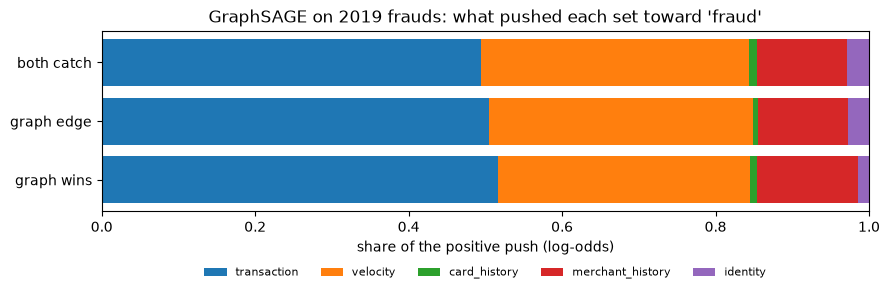

In [14]:
fig, ax = plt.subplots(figsize=(9, 3.2))
left = np.zeros(shares.height)
for g_ in G.GROUPS:
    ax.barh(shares["set"], shares[g_], left=left, label=g_); left += shares[g_].to_numpy()
ax.set_xlim(0, 1); ax.set_xlabel("share of the positive push (log-odds)")
ax.set_title("GraphSAGE on 2019 frauds: what pushed each set toward 'fraud'")
ax.legend(frameon=False, fontsize=8, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.25))
plt.tight_layout(); plt.show()
if not SAMPLE:
    shares.write_csv(out / "graphsage_where_the_graph_wins.csv")

## Reading the results (full run, 3 Oct 2026)

**Both explanations are exact, and checked.** TreeSHAP sums to XGBoost's margin within 1.1e-05 (float32) and equals the `shap` library's TreeExplainer exactly. GraphSAGE's group values sum to the score difference within 3.6e-15, and the full coalition reproduces the served score within 7.8e-08 — so the explanation is of the input serving actually scored.

**XGBoost's false positives have one cause.** Every top false positive is an *online* transaction, and `Chip = Online Transaction` is its largest push (+2 to +3 log-odds). Its true positives look different: location (`Zip`, `MCC`, `City`) plus 24-hour velocity. The champion has learned "online is risky"; that is the rule behind most of the alerts an analyst would dismiss.

**GraphSAGE's highest alerts are driven by velocity (47% of the positive push) and the transaction itself (41%).** The graph groups contribute little at the very top: merchant history 7%, identity 3%, card history 2%. This is a caveat on the relational story, not a contradiction of it: these are its most confident alerts, saturated near 1.0, so section 6 looks where the lead is actually earned.

**The two models disagree in instructive ways.** Transaction 8443998 is legitimate: XGBoost scores it 0.004, GraphSAGE 1.0, entirely on velocity (+24.8 log-odds) — a burst of spending GraphSAGE reads as fraud and XGBoost does not. Disagreements like this are where an explanation earns its keep.

**For production:** `fraud.explain.tree.explain_rows` gives reason codes per alert in microseconds; `fraud.explain.graph.explain` takes ~0.2 s per alert, cheap enough to run on every GraphSAGE alert (not every request) once the neighbourhood comes from `store.fetch_neighbourhood_once`. An `/explain` endpoint is the natural next step.

**Where GraphSAGE wins (section 6) — and a correction.** In each model's top 5,000 alerts GraphSAGE catches 1,544 frauds to XGBoost's 1,156. Group Shapley on the 51 frauds only it ranks highly, 50 it edges and 50 both catch gives the same profile for all three: transaction ~50%, velocity ~35%, graph groups ~15%. This notebook first read that as "the graph is not what wins it". **That reading was wrong, and the Phase 6 ablation shows why.** Replaying all of 2019 with the neighbourhood removed (velocity kept) collapses GraphSAGE from **0.4665 to 0.0418** AUC-PR (P@100 0.71 → 0.05; Δ −0.425, 95% CI −0.445 to −0.404) — below XGBoost. Shapley measures how far each group pushes *a fraud's* score from a baseline; it does not measure how the model *ranks* frauds among 1.7M legitimate transactions, and the ranking is what depends on the graph. Group shares on positives are not a measure of where discrimination comes from.

One caveat keeps the claim precise: an empty neighbourhood is also something the model never saw in training, so the ablation proves the served model **depends** on its neighbourhood; a shuffled-neighbour control is the clean test of whether the *specific* relationships carry the signal.